## 1 Introduction
Bài nghiên cứu này tập trung vào việc làm rõ tầm ảnh hưởng của các đặc tính âm thanh kỹ thuật số đối với mức độ thành công (thương mại) của một tác phẩm âm nhạc.

*   **Câu hỏi nghiên cứu:** Các chỉ số âm nhạc như độ nhảy (`danceability_%`) hay năng lượng (`energy_%`) có tác động thuận chiều đến tổng lượt stream không?
*   **Giả thuyết nghiên cứu:**
    *   $H_0$: Độ nhảy và năng lượng không có tác động hoặc tác động nghịch chiều đến lượt stream.
    *   $H_1$: Độ nhảy và năng lượng có tác động thuận chiều tích cực đến lượt stream.

## 2 Mô tả dữ liệu và tiền xử lý

### a. Mô tả dữ liệu
#### Nguồn dữ liệu

Dataset: Top Spotify Songs 2023 Dataset (Kaggle)

Tập dữ liệu bao gồm các thông tin về những bài hát thành công nhất trên nền tảng Spotify trong năm 2023. Để phục vụ cho câu hỏi nghiên cứu về mối quan hệ giữa đặc tính âm thanh và mức độ thành công thương mại, các biến số được lựa chọn và phân loại cấu trúc như sau:

| Tên biến | Kiểu dữ liệu | Vai trò trong mô hình | Ý nghĩa chức năng |
| :--- | :--- | :--- | :--- |
| `streams` | Số nguyên (`int64`) | **Biến phụ thuộc** (Target - $y$) | Tổng số lượt nghe tích lũy trên Spotify. Đây là thước đo chính cho sự thành công thương mại. |
| `log_streams` | Số thực (`float64`) | **Biến phụ thuộc** (Sau biến đổi) | Giá trị Logarit tự nhiên của lượt stream ($\ln(1 + \text{streams})$), dùng để xử lý phân phối lệch và đảm bảo giả định hồi quy. |
| `danceability_%` | Số nguyên (`int64`) | **Biến độc lập** (Predictor - $x_1$) | Độ phù hợp của bài hát đối với việc nhảy nhảy (thang điểm 0 - 100%), dựa trên nhịp điệu, độ ổn định của nhịp. |
| `energy_%` | Số nguyên (`int64`) | **Biến độc lập** (Predictor - $x_2$) | Phép đo tốc độ và cường độ âm thanh (thang điểm 0 - 100%), đại diện cho độ sôi động, mạnh mẽ của bài hát. |
| `artist(s)_name` | Chuỗi ký tự (`str`) | Biến phân loại / Định danh | Tên (các) nghệ sĩ trình bày bài hát. |
| `released_year` | Số nguyên (`int64`) | Biến thời gian / Kiểm soát | Năm bài hát chính thức được phát hành. |

*Lưu ý về thang đo:* Hai biến độc lập chính (`danceability_%` và `energy_%`) được Spotify chuẩn hóa dưới dạng tỷ lệ phần trăm (%), giúp mô hình hồi quy OLS dễ giải thích ý nghĩa hệ số biên tế ($\beta$) hơn.

#### b. Tiền xử lý: Import thư viện và làm sạch dữ liệu

In [1]:
# Auto-generated code for data analysis after cleaning
%run data_cleaning.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the cleaned data
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")
print(f"Dataset size for analysis: {df.shape}")

Exception: File `'data_cleaning.ipynb'` not found.

In [ ]:
selected_columns = ['streams', 'log_streams', 'danceability_%', 'energy_%', 'released_year']

print("--- Statistical Summary of Key Variables ---")
# Check data types and count of non-null values
print(df[selected_columns].info())

# Display mathematical distribution (Min, Max, Mean) for EDA preparation
display(df[selected_columns].describe().round(2))

--- Statistical Summary of Key Variables ---
<class 'pandas.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   streams         952 non-null    int64  
 1   log_streams     952 non-null    float64
 2   danceability_%  952 non-null    int64  
 3   energy_%        952 non-null    int64  
 4   released_year   952 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 37.3 KB
None


,streams,log_streams,danceability_%,energy_%,released_year
count,9.520000e+02,952.00,952.00,952.00,952.00
mean,5.141374e+08,19.51,66.98,64.27,2018.29
std,5.668569e+08,1.15,14.63,16.56,11.01
min,2.762000e+03,7.92,23.00,9.00,1930.00
25%,1.416362e+08,18.77,57.00,53.00,2020.00
50%,2.905309e+08,19.49,69.00,66.00,2022.00
75%,6.738690e+08,20.33,78.00,77.00,2022.00
max,3.703895e+09,22.03,96.00,97.00,2023.00


## 3 Phân tích khám phá dữ liệu (EDA)
### a. Phân tích đơn biến (Univariate Analysis)
* Trực quan hóa phân phối của biến mục tiêu (`streams` và `log_streams`) bằng Histogram để đánh giá độ lệch.
* Sử dụng Boxplot để xác định các bài hát "siêu hit" (Outliers vượt trội trên thị trường).
* Thống kê mô tả xu hướng trung tâm (Mean, Median) của các đặc tính âm thanh kỹ thuật số.

### b. Phân tích đặc tính âm nhạc ảnh hưởng đến độ hot (Audio Features vs. Hit Status)
* Biểu đồ Scatter plot & Đường xu hướng (Trendline):
    * `danceability_%` tác động thế nào đến `log_streams`?
    * `energy_%` tác động thế nào đến `log_streams`?
* Biểu đồ Boxplot phân tích nhạc lý nâng cao:
    * Mức độ thành công của bài hát dựa trên Tông nhạc (`key`) và Thể thức (`mode` - Trưởng/Thứ).
    * Tác động của tốc độ nhịp điệu (`bpm`) đến tổng lượt nghe.

### c. Phân tích các yếu tố lan tỏa và phân phối (Distribution & Contextual Factors)
* Biểu đồ cột so sánh: Bài hát Solo vs. Bài hát Hợp tác (`artist_count`) – Xu hướng nào dễ tạo hit hơn?
* Biểu đồ đường (Line chart): Xu hướng phát hành bài hit theo các tháng trong năm (`released_month`).
* Ma trận tương quan toàn diện (Correlation Heatmap) giữa các chỉ số âm thanh (`danceability_%`, `energy_%`, `valence_%`, `acousticness_%`) và độ phủ Playlist trên các nền tảng (Apple, Deezer, Spotify) để kiểm tra hiện tượng đa cộng tuyến.

## 4 Kiểm định giả thuyết & Mô hình hóa
### a. Phân tích tương quan (Correlation Analysis)
* **Kiểm định Pearson Correlation:** Đánh giá mức độ chặt chẽ của mối quan hệ tuyến tính giữa các audio features với biến `log_streams`.
* **Kiểm định Spearman Rank Correlation:** Kiểm tra mối quan hệ đơn điệu (phi tuyến) để phòng trường hợp dữ liệu có phân phối bất thường.

### b. Xây dựng mô hình Hồi quy tuyến tính bội (Multiple Linear Regression)
Xây dựng mô hình OLS để đánh giá đồng thời tác động của độ nhảy và năng lượng âm thanh lên quy mô lượt stream:

$$\text{log\_streams} = \beta_0 + \beta_1 \cdot \text{danceability\_\%} + \beta_2 \cdot \text{energy\_\%} + \epsilon$$

*Trong đó:* $\beta_0$ là hằng số chặn; $\beta_1, \beta_2$ là các hệ số hồi quy biên tế; $\epsilon$ là sai số ngẫu nhiên.

### c. Kiểm tra các giả định của mô hình hồi quy (OLS Assumptions Testing)
* **Giả định về phân phối chuẩn của sai số (Normality of Residuals):** Sử dụng biểu đồ Q-Q Plot và kiểm định Jarque-Bera.
* **Giả định về phương sai sai số không đổi (Homoscedasticity):** Vẽ biểu đồ Residuals vs Fitted plot để quan sát độ phân tán.
* **Kiểm tra đa cộng tuyến (Multicollinearity):** Tính toán chỉ số VIF (Variance Inflation Factor) giữa `danceability_%` và `energy_%`.

### d. Đánh giá và phân tích kết quả mô hình
* Đánh giá mức độ phù hợp của toàn bộ mô hình thông qua hệ số xác định hiệu chỉnh $R^2$ điều chỉnh ($Adjusted-R^2$).
* Kiểm định ý nghĩa của các hệ số hồi quy dựa trên giá trị trị thống kê $t$ và $p\text{-value}$ để đưa ra quyết định bác bỏ hay chấp nhận các giả thuyết $H_0/H_1$ đã đề xuất ở Mục 1.

## 5 Kết luận & Giải thích kết quả (Conclusion & Discussion)
* Trả lời trực tiếp câu hỏi nghiên cứu: Giả thuyết thuận chiều là Đúng hay Sai dựa trên dữ liệu thực tế.
* Góc nhìn thực tế: Tại sao lại có kết quả đó? (Ví dụ: Nếu không thuận chiều, có thể vì năm 2023 người nghe chuộng nhạc lofi, chillout hơn là nhạc nhảy sôi động).
* Hạn chế của đề tài: Dữ liệu chỉ gói gọn trong năm 2023, chưa tính đến yếu tố marketing, độ nổi tiếng sẵn có của nghệ sĩ (như Taylor Swift, The Weeknd).


## 6 Ý nghĩa thực tiễn (Insights)

Kết quả nghiên cứu có thể giúp:

* Nghệ sĩ tối ưu phong cách âm nhạc
* Producer hiểu xu hướng thị hiếu
* Xây dựng mô hình dự đoán độ phổ biến bài hát
* Hỗ trợ recommendation system cho nền tảng streaming

### Data Loading and Descriptive Statistics

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc luôn file dữ liệu SẠCH từ thư mục processed của bạn nhóm
# Dùng đường dẫn tương đối này thì ai trong nhóm mở máy lên cũng chạy được
df = pd.read_csv("../datasets/processed/cleaned_spotify_2023.csv")

# Xem qua các thông số trung bình, lớn nhất, nhỏ nhất
df[["danceability_%", "energy_%", "streams"]].describe()

,danceability_%,energy_%,streams
count,952.000000,952.000000,9.520000e+02
mean,66.984244,64.274160,5.141374e+08
std,14.631282,16.558517,5.668569e+08
min,23.000000,9.000000,2.762000e+03
25%,57.000000,53.000000,1.416362e+08
50%,69.000000,66.000000,2.905309e+08
75%,78.000000,77.000000,6.738690e+08
max,96.000000,97.000000,3.703895e+09


### Correlation Analysis (Heatmap)

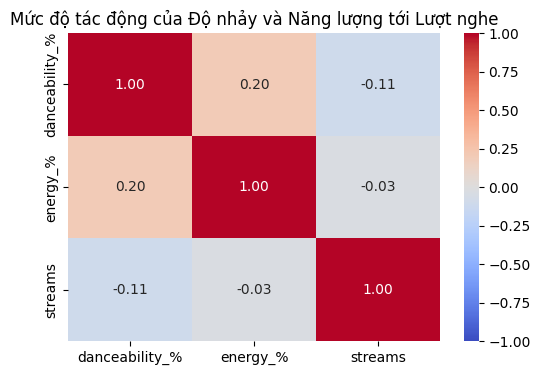

In [3]:
# Tính ma trận tương quan giữa 3 chỉ số chính
corr = df[["danceability_%", "energy_%", "streams"]].corr()

# Vẽ biểu đồ nhiệt dạng bảng màu cực đẹp
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Mức độ tác động của Độ nhảy và Năng lượng tới Lượt nghe")
plt.show()

### Trend and Regression Analysis

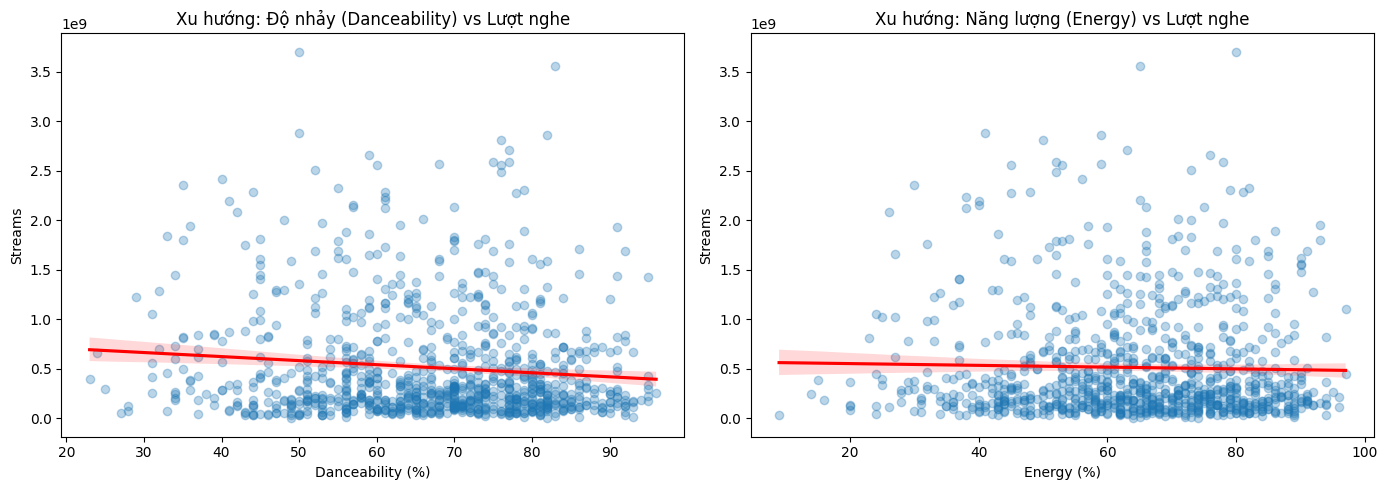

In [4]:
plt.figure(figsize=(14, 5))

# Biểu đồ bên trái: Độ nhảy vs Lượt nghe
plt.subplot(1, 2, 1)
sns.regplot(data=df, x="danceability_%", y="streams", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Xu hướng: Độ nhảy (Danceability) vs Lượt nghe")
plt.xlabel("Danceability (%)")
plt.ylabel("Streams")

# Biểu đồ bên phải: Năng lượng vs Lượt nghe
plt.subplot(1, 2, 2)
sns.regplot(data=df, x="energy_%", y="streams", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Xu hướng: Năng lượng (Energy) vs Lượt nghe")
plt.xlabel("Energy (%)")
plt.ylabel("Streams")

plt.tight_layout()
plt.show()

### Data Binning and Group Comparison

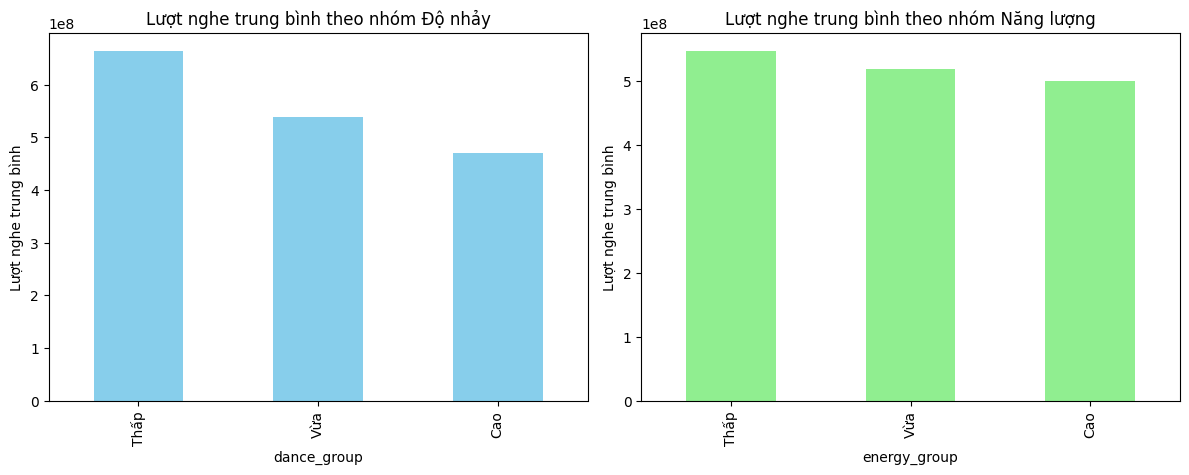

In [5]:
# 1. Chia nhóm cho cột Độ nhảy
df["dance_group"] = pd.cut(df["danceability_%"], bins=[0, 40, 70, 100], labels=["Thấp", "Vừa", "Cao"])

# 2. Chia nhóm cho cột Năng lượng
df["energy_group"] = pd.cut(df["energy_%"], bins=[0, 40, 70, 100], labels=["Thấp", "Vừa", "Cao"])

# 3. Vẽ 2 biểu đồ cột so sánh lượt nghe trung bình
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.groupby("dance_group")["streams"].mean().plot(kind="bar", color="skyblue")
plt.title("Lượt nghe trung bình theo nhóm Độ nhảy")
plt.ylabel("Lượt nghe trung bình")

plt.subplot(1, 2, 2)
df.groupby("energy_group")["streams"].mean().plot(kind="bar", color="lightgreen")
plt.title("Lượt nghe trung bình theo nhóm Năng lượng")
plt.ylabel("Lượt nghe trung bình")

plt.tight_layout()
plt.show()